In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("Autism_Data.arff")
df.head(20)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO
5,1,1,1,1,1,0,1,1,1,1,...,m,Others,yes,no,'United States',no,9,'18 and more',Self,YES
6,0,1,0,0,0,0,0,1,0,0,...,f,Black,no,no,'United States',no,2,'18 and more',Self,NO
7,1,1,1,1,0,0,0,0,1,0,...,m,White-European,no,no,'New Zealand',no,5,'18 and more',Parent,NO
8,1,1,0,0,1,0,0,1,1,1,...,m,White-European,no,no,'United States',no,6,'18 and more',Self,NO
9,1,1,1,1,0,1,1,1,1,0,...,m,Asian,yes,yes,Bahamas,no,8,'18 and more','Health care professional',YES


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   A1_Score         704 non-null    int64
 1   A2_Score         704 non-null    int64
 2   A3_Score         704 non-null    int64
 3   A4_Score         704 non-null    int64
 4   A5_Score         704 non-null    int64
 5   A6_Score         704 non-null    int64
 6   A7_Score         704 non-null    int64
 7   A8_Score         704 non-null    int64
 8   A9_Score         704 non-null    int64
 9   A10_Score        704 non-null    int64
 10  age              704 non-null    str  
 11  gender           704 non-null    str  
 12  ethnicity        704 non-null    str  
 13  jundice          704 non-null    str  
 14  austim           704 non-null    str  
 15  contry_of_res    704 non-null    str  
 16  used_app_before  704 non-null    str  
 17  result           704 non-null    int64
 18  age_desc         704 

In [4]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum()

A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                 2
gender              0
ethnicity          95
jundice             0
austim              0
contry_of_res       0
used_app_before     0
result              0
age_desc            0
relation           95
Class/ASD           0
dtype: int64

In [5]:
df.dropna(inplace=True)
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [6]:
df.shape

(609, 21)

In [7]:
cols_to_drop = ['jundice', 'austim', 'contry_of_res', 'age_desc', 'relation', 'ethnicity']
cols_present = [c for c in cols_to_drop if c in df.columns]
if cols_present:
    df.drop(cols_present, axis=1, inplace=True)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
A1_Score,609.0,0.740558,0.438689,0.0,0.0,1.0,1.0,1.0
A2_Score,609.0,0.469622,0.499487,0.0,0.0,0.0,1.0,1.0
A3_Score,609.0,0.481117,0.500054,0.0,0.0,0.0,1.0,1.0
A4_Score,609.0,0.520525,0.499989,0.0,0.0,1.0,1.0,1.0
A5_Score,609.0,0.525452,0.499762,0.0,0.0,1.0,1.0,1.0
A6_Score,609.0,0.307061,0.461654,0.0,0.0,0.0,1.0,1.0
A7_Score,609.0,0.428571,0.495278,0.0,0.0,0.0,1.0,1.0
A8_Score,609.0,0.665025,0.472370,0.0,0.0,1.0,1.0,1.0
A9_Score,609.0,0.341544,0.474617,0.0,0.0,0.0,1.0,1.0
A10_Score,609.0,0.597701,0.490765,0.0,0.0,1.0,1.0,1.0


In [8]:
pd.set_option('future.no_silent_downcasting', True)
df.replace({'yes': 1, 'no': 0}, inplace=True)
df.replace({'m': 1, 'f': 0}, inplace=True)

X = df.drop('Class/ASD', axis=1)
Y = df['Class/ASD']

C:\Users\moazm\AppData\Local\Temp\ipykernel_29628\770017726.py:1: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [9]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [12]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)

print("KNN Train Score:", knn_model.score(X_train, Y_train))
print("KNN Test  Score:", knn_model.score(X_test,  Y_test))

KNN Train Score: 0.9774127310061602
KNN Test  Score: 0.9508196721311475


In [13]:
Y_pred_knn = knn_model.predict(X_test)
print("--- KNN Results ---")
print("Accuracy:", accuracy_score(Y_test, Y_pred_knn))
print(classification_report(Y_test, Y_pred_knn))

--- KNN Results ---
Accuracy: 0.9508196721311475
              precision    recall  f1-score   support

          NO       0.99      0.94      0.96        81
         YES       0.89      0.98      0.93        41

    accuracy                           0.95       122
   macro avg       0.94      0.96      0.95       122
weighted avg       0.95      0.95      0.95       122



In [14]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, Y_train)

Y_pred_lr = lr_model.predict(X_test)
print("--- Logistic Regression Results ---")
print("Accuracy:", accuracy_score(Y_test, Y_pred_lr))
print(classification_report(Y_test, Y_pred_lr))

--- Logistic Regression Results ---
Accuracy: 1.0
              precision    recall  f1-score   support

          NO       1.00      1.00      1.00        81
         YES       1.00      1.00      1.00        41

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122



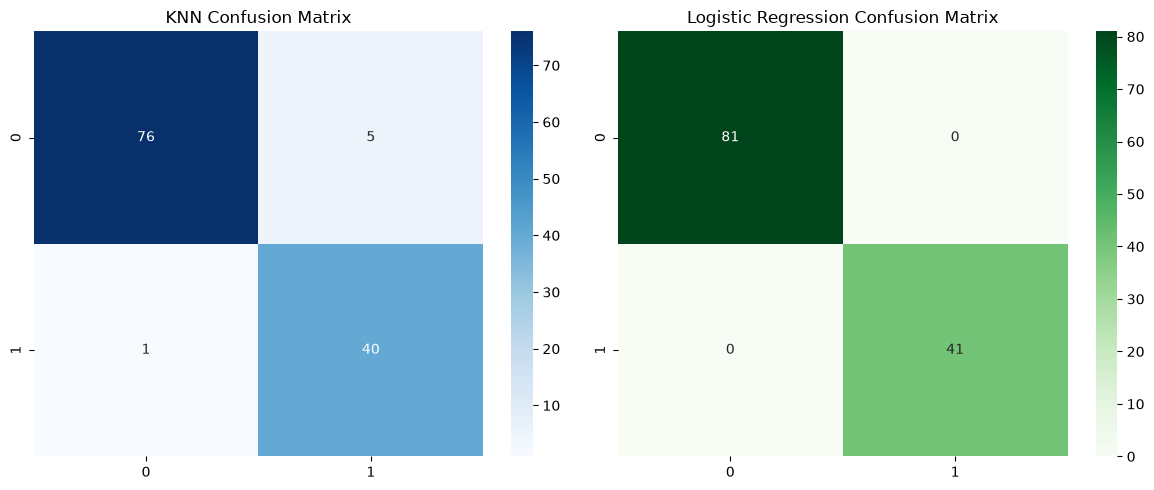

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(Y_test, Y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(Y_test, Y_pred_lr), annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')

plt.tight_layout()
plt.show()